# MSDS 696 · Week 2 — Vetting the Churn Dataset
### Model-together: what this data *can* answer, and where it can't

This is the live demo for Week 2. The running example is `customer_churn.csv` (~1,800 telecom customers).
The point isn't to build a churn model — it's to **interrogate the data against the question** before we
trust it. We'll do the normal EDA first (the honest wins), then spend most of our time **naming the
limits with evidence** — because *"every dataset has limits; name them before someone else does."*

We organize around the four questions from the deck: **Fit · Provenance · Limits · Feasibility.**

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pathlib import Path

# --- deck palette ---
NAVY, CORAL, GREEN, SLATE = "#1E2761", "#E5544B", "#2E8B6F", "#64748B"
plt.rcParams.update({
    "figure.figsize": (7.2, 4.0), "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": NAVY,
    "font.size": 11, "axes.edgecolor": "#CBD5E1", "axes.labelcolor": SLATE,
})

# find the dataset wherever this notebook lives
csv = next((c for c in [Path("customer_churn.csv"), Path("../customer_churn.csv"),
                        Path("../../customer_churn.csv"), Path("../../../customer_churn.csv")]
            if c.exists()), None)
df = pd.read_csv(csv)
print("Loaded:", csv, "| shape:", df.shape)
df.head()

Loaded: ../../customer_churn.csv | shape: (1800, 10)


,customer_id,tenure_months,contract_type,monthly_charges,num_support_calls,failed_logins_last_month,payment_method,paperless_billing,avg_monthly_usage_gb,churned
0,C100000,28,One year,68.81,0,0,Credit card,1,13.5,0
1,C100001,40,One year,70.59,0,2,Mailed check,1,24.5,0
2,C100002,17,One year,59.89,1,0,Credit card,1,13.0,0
3,C100003,16,Month-to-month,61.36,2,0,Electronic check,1,18.4,0
4,C100004,66,Two year,75.20,2,3,Mailed check,0,19.3,0


## 1. Quick EDA — what's actually in the table

In [2]:
print("Rows, cols:", df.shape)
print("\nColumns & types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum())
print(f"\nOverall churn rate: {df.churned.mean():.1%}")

Rows, cols: (1800, 10)

Columns & types:
customer_id                  object
tenure_months                 int64
contract_type                object
monthly_charges             float64
num_support_calls             int64
failed_logins_last_month      int64
payment_method               object
paperless_billing             int64
avg_monthly_usage_gb        float64
churned                       int64
dtype: object

Missing values per column:
customer_id                 0
tenure_months               0
contract_type               0
monthly_charges             0
num_support_calls           0
failed_logins_last_month    0
payment_method              0
paperless_billing           0
avg_monthly_usage_gb        0
churned                     0
dtype: int64

Overall churn rate: 37.5%


In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1800,1800,C100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,1800.0,NaN,NaN,NaN,36.048889,20.56746,1.0,18.0,36.0,54.0,72.0
contract_type,1800,3,Month-to-month,1025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_charges,1800.0,NaN,NaN,NaN,69.340306,24.632242,20.0,51.785,69.035,85.9625,140.0
num_support_calls,1800.0,NaN,NaN,NaN,1.217222,1.084549,0.0,0.0,1.0,2.0,6.0
failed_logins_last_month,1800.0,NaN,NaN,NaN,0.81,0.901799,0.0,0.0,1.0,1.0,6.0
payment_method,1800,4,Electronic check,622,NaN,NaN,NaN,NaN,NaN,NaN,NaN
paperless_billing,1800.0,NaN,NaN,NaN,0.588889,0.492172,0.0,0.0,1.0,1.0,1.0
avg_monthly_usage_gb,1800.0,NaN,NaN,NaN,18.027222,7.100227,1.0,13.2,18.2,22.9,40.3
churned,1800.0,NaN,NaN,NaN,0.375,0.484257,0.0,0.0,0.0,1.0,1.0


**Note already:** ten columns, **no missing values**, and — importantly — look at what's *not* here:
no dates, no free-text notes, no **reason the customer left**. Hold that thought; it becomes Limit #1.

## 2. What the data CAN show — the honest wins
These three relationships are real and defensible. This is the part you'd put on a slide.

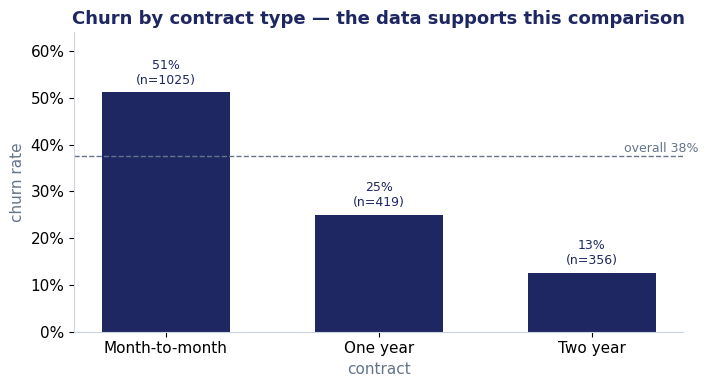

In [4]:
def churn_bar(group, order=None, title="", xlabel="", color=NAVY, ax=None):
    r = df.groupby(group).churned.mean()
    if order is not None: r = r.reindex(order)
    n = df.groupby(group).size().reindex(r.index)
    if ax is None: fig, ax = plt.subplots()
    bars = ax.bar(r.index.astype(str), r.values, color=color, width=0.6)
    ax.axhline(df.churned.mean(), color=SLATE, ls="--", lw=1)
    ax.text(len(r)-0.5, df.churned.mean()+0.01, f"overall {df.churned.mean():.0%}",
            color=SLATE, ha="right", fontsize=9)
    for b, v, nn in zip(bars, r.values, n):
        ax.text(b.get_x()+b.get_width()/2, v+0.012, f"{v:.0%}\n(n={nn})",
                ha="center", va="bottom", fontsize=9, color=NAVY)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("churn rate")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0)); ax.set_ylim(0, max(r.values)*1.25)
    return ax

churn_bar("contract_type", order=["Month-to-month","One year","Two year"],
          title="Churn by contract type — the data supports this comparison",
          xlabel="contract", color=NAVY)
plt.tight_layout(); plt.show()

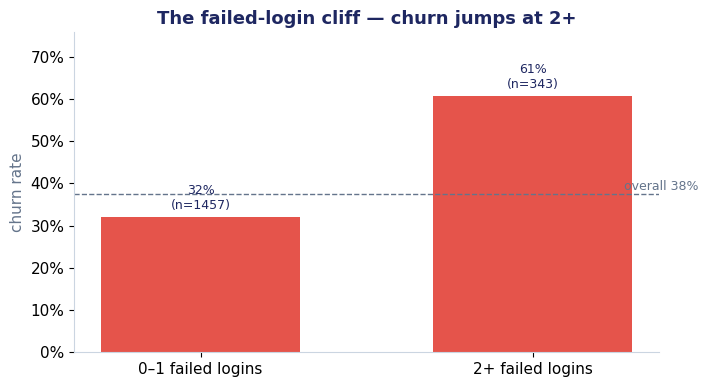

In [5]:
df["failed_login_bucket"] = np.where(df.failed_logins_last_month>=2, "2+ failed logins", "0–1 failed logins")
churn_bar("failed_login_bucket", order=["0–1 failed logins","2+ failed logins"],
          title="The failed-login cliff — churn jumps at 2+", xlabel="", color=CORAL)
plt.tight_layout(); plt.show()

/sessions/awesome-optimistic-heisenberg/tmp/ipykernel_5/3681289554.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  r = df.groupby(group).churned.mean()
/sessions/awesome-optimistic-heisenberg/tmp/ipykernel_5/3681289554.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n = df.groupby(group).size().reindex(r.index)


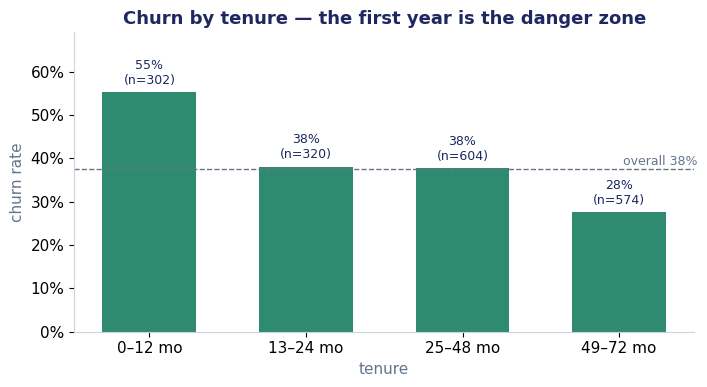

In [6]:
# tenure: first-year customers churn far more
df["tenure_band"] = pd.cut(df.tenure_months, [0,12,24,48,72],
                           labels=["0–12 mo","13–24 mo","25–48 mo","49–72 mo"])
churn_bar("tenure_band", title="Churn by tenure — the first year is the danger zone",
          xlabel="tenure", color=GREEN)
plt.tight_layout(); plt.show()

These are **fit** wins: the data answers *"who churns more?"* — month-to-month (~51%), 2+ failed
logins (~61%), first-year customers (~55%). Now the hard part.

## 3. Name the limits — with evidence
This is the real skill. Each limit below comes with a picture, because *"it has limits"* is a hand-wave;
*"here's the limit and here's the evidence"* is analysis.

### Limit 1 — No *why*. The data says **who**, never **because**.
There is no `reason_for_leaving` column. So even the single strongest split still leaves a huge chunk of
churn unexplained — the "why" is interpretation you'll argue, not a fact the table hands you.

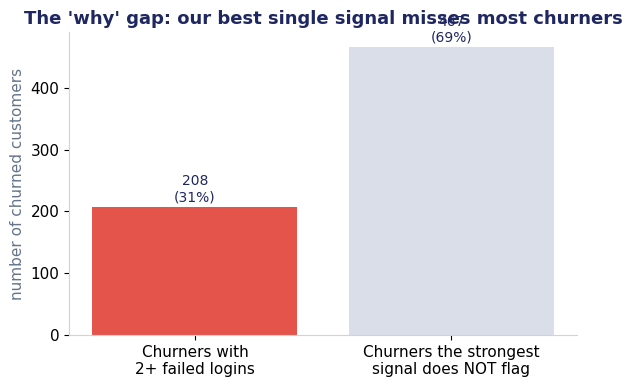

69% of churners have 0–1 failed logins — the data offers no reason for them.


In [7]:
# Even our best single signal (failed logins) explains only part of churn
tot_churn = df.churned.sum()
cliff_churn = df[df.failed_logins_last_month>=2].churned.sum()
labels = ["Churners with\n2+ failed logins", "Churners the strongest\nsignal does NOT flag"]
vals = [cliff_churn, tot_churn - cliff_churn]
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(labels, vals, color=[CORAL, "#D9DEE8"])
for i,v in enumerate(vals): ax.text(i, v+8, f"{v}\n({v/tot_churn:.0%})", ha="center", color=NAVY, fontsize=10)
ax.set_title("The 'why' gap: our best single signal misses most churners")
ax.set_ylabel("number of churned customers"); plt.tight_layout(); plt.show()
print(f"{vals[1]/tot_churn:.0%} of churners have 0–1 failed logins — the data offers no reason for them.")

### Limit 2 — It's a **snapshot, not a timeline.**
No dates, no event order, no post-cancellation rows. `tenure_months` is the *only* time signal, and it's a
single number per customer. We can't model *when* someone will churn, what happened right before, or what
they did after they left.

Date / event / sequence columns available: NONE
Only time-related field: tenure_months (a single snapshot value, range 1–72 months)


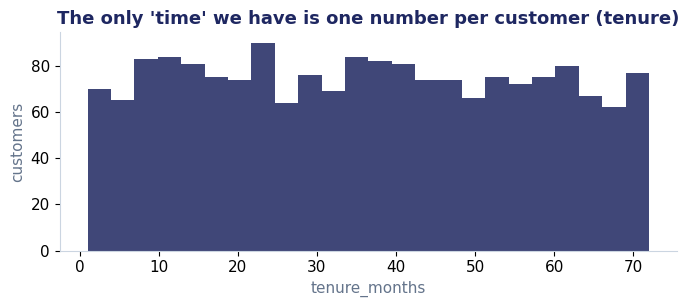

In [8]:
time_cols = [c for c in df.columns if any(k in c.lower() for k in ["date","time","month_","event","ts"])]
print("Date / event / sequence columns available:", time_cols if time_cols else "NONE")
print("Only time-related field:", "tenure_months (a single snapshot value, range "
      f"{df.tenure_months.min()}–{df.tenure_months.max()} months)")
fig, ax = plt.subplots(figsize=(7,3.2))
ax.hist(df.tenure_months, bins=24, color=NAVY, alpha=.85)
ax.set_title("The only 'time' we have is one number per customer (tenure)")
ax.set_xlabel("tenure_months"); ax.set_ylabel("customers"); plt.tight_layout(); plt.show()

### Limit 3 — A **thin behavioral window.** `failed_logins_last_month` = *last month only.*
Our strongest behavioral signal covers ~30 days, not the customer's history — and the high-signal group
is small, so we're leaning hard on a narrow, recent slice.

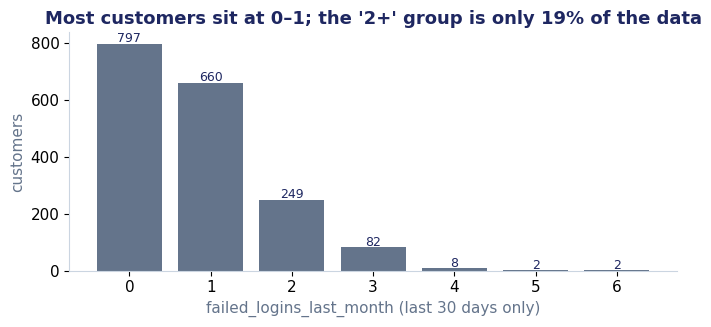

In [9]:
vc = df.failed_logins_last_month.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7,3.4))
ax.bar(vc.index.astype(str), vc.values, color=SLATE)
share_2plus = (df.failed_logins_last_month>=2).mean()
ax.set_title(f"Most customers sit at 0–1; the '2+' group is only {share_2plus:.0%} of the data")
ax.set_xlabel("failed_logins_last_month (last 30 days only)"); ax.set_ylabel("customers")
for x,v in zip(vc.index, vc.values): ax.text(x, v+5, str(v), ha="center", fontsize=9, color=NAVY)
plt.tight_layout(); plt.show()

### Limit 4 — **Correlation ≠ cause.** Contract type is tangled up with tenure.
Month-to-month customers churn at 51% vs 13% on two-year — but two-year customers have also been around
*far longer*. Does the contract cause loyalty, or do loyal customers self-select into long contracts?
The raw comparison can't tell you. Watch the tenure distributions pull apart by contract:

/sessions/awesome-optimistic-heisenberg/tmp/ipykernel_5/1169357890.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True, medianprops=dict(color="white", lw=2))


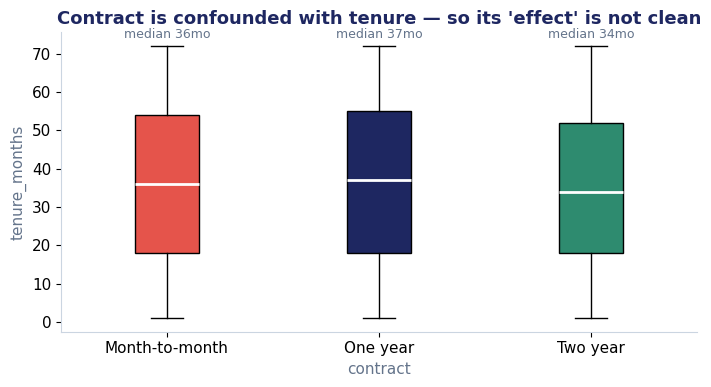

In [10]:
order = ["Month-to-month","One year","Two year"]
data = [df.loc[df.contract_type==c, "tenure_months"].values for c in order]
fig, ax = plt.subplots(figsize=(7.2,4))
bp = ax.boxplot(data, labels=order, patch_artist=True, medianprops=dict(color="white", lw=2))
for patch, col in zip(bp["boxes"], [CORAL, NAVY, GREEN]): patch.set_facecolor(col)
ax.set_title("Contract is confounded with tenure — so its 'effect' is not clean")
ax.set_ylabel("tenure_months"); ax.set_xlabel("contract")
for i,c in enumerate(order,1):
    ax.text(i, df.tenure_months.max()+2, f"median {int(np.median(df.loc[df.contract_type==c,'tenure_months']))}mo",
            ha="center", fontsize=9, color=SLATE)
plt.tight_layout(); plt.show()

In [11]:
# Stratify: within the SAME tenure band, does contract still separate churn? (partly yes, partly tenure)
piv = (df.pivot_table(index="tenure_band", columns="contract_type", values="churned", aggfunc="mean")
         .reindex(columns=order))
print("Churn rate by tenure band x contract (raw gaps shrink once tenure is held roughly fixed):")
(piv*100).round(0)

/sessions/awesome-optimistic-heisenberg/tmp/ipykernel_5/2444642862.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = (df.pivot_table(index="tenure_band", columns="contract_type", values="churned", aggfunc="mean")


Churn rate by tenure band x contract (raw gaps shrink once tenure is held roughly fixed):


contract_type,Month-to-month,One year,Two year
tenure_band,,,
0–12 mo,73.0,38.0,26.0
13–24 mo,52.0,35.0,8.0
25–48 mo,52.0,22.0,16.0
49–72 mo,39.0,17.0,5.0


### Limit 5 — **Slice it and the cells get thin fast.** Small n ⇒ shaky percentages.
Headline rates are on ~1,800 rows, but the moment you cross two dimensions (contract × login behavior),
some cells are tiny — and a churn rate from a handful of people has a wide error bar. Numbers on the tiles
are **cell counts**; the ± is a rough 95% margin.

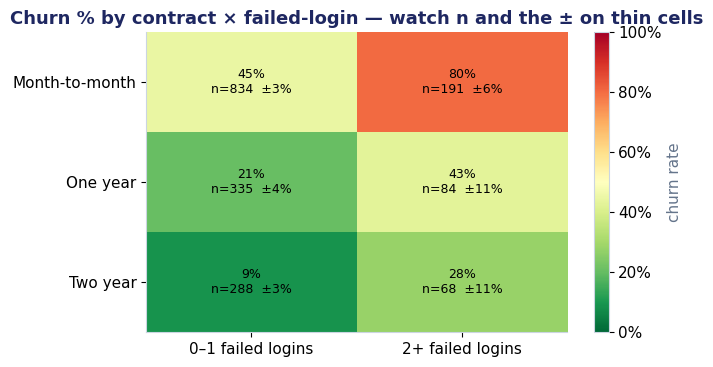

In [12]:
ct = df.groupby(["contract_type","failed_login_bucket"])
rate = ct.churned.mean().unstack().reindex(order)
cnt  = ct.size().unstack().reindex(order)
fig, ax = plt.subplots(figsize=(7,3.8))
im = ax.imshow(rate.values, cmap="RdYlGn_r", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(rate.shape[1])); ax.set_xticklabels(rate.columns)
ax.set_yticks(range(rate.shape[0])); ax.set_yticklabels(rate.index)
for i in range(rate.shape[0]):
    for j in range(rate.shape[1]):
        n = int(cnt.values[i,j]); p = rate.values[i,j]
        moe = 1.96*np.sqrt(p*(1-p)/n) if n>0 else 0
        ax.text(j, i, f"{p:.0%}\nn={n}  ±{moe:.0%}", ha="center", va="center",
                fontsize=9, color="black")
ax.set_title("Churn % by contract × failed-login — watch n and the ± on thin cells")
plt.colorbar(im, ax=ax, format=PercentFormatter(1.0), label="churn rate")
plt.tight_layout(); plt.show()

### Limit 6 — **One company. Don't assume it generalizes.**
Every row is *this* provider's customers, priced and marketed *this* way. There's nothing in the file that
proves the patterns hold for another market, segment, or era — that's a **provenance** limit no chart can
fix. State it out loud; it's what keeps the analysis honest.

In [13]:
print("What we know about provenance FROM THE DATA ALONE:")
print("• Source system / vendor .......... not in the file")
print("• Time period covered ............. not in the file (no dates)")
print("• How rows were sampled ........... not in the file")
print("• Which market / geography ........ not in the file")
print("\n=> Generalization is an assumption, not a finding. Say so.")

What we know about provenance FROM THE DATA ALONE:
• Source system / vendor .......... not in the file
• Time period covered ............. not in the file (no dates)
• How rows were sampled ........... not in the file
• Which market / geography ........ not in the file

=> Generalization is an assumption, not a finding. Say so.


### Limit 7 — **Leakage watch.** Is a 'predictor' actually measured *after* the outcome?
`failed_logins_last_month` separates churn strongly — but if that last month overlaps the customer's exit,
the behavior may be a *symptom* of leaving, not a usable early-warning signal. Below: a **deliberately
leaky** column (built from the label) shows what "too good to be true" looks like, so you can smell it in
real features.

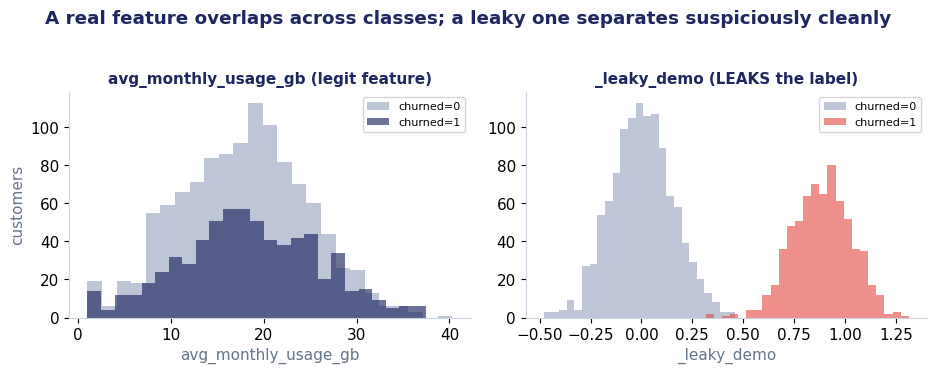

In [14]:
rng = np.random.default_rng(0)
# a fake feature that peeks at the outcome ~ what leakage looks like
df["_leaky_demo"] = df.churned*0.9 + rng.normal(0, 0.15, len(df))
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
for ax, col, name, color in [(axes[0], "avg_monthly_usage_gb", "avg_monthly_usage_gb (legit feature)", NAVY),
                             (axes[1], "_leaky_demo", "_leaky_demo (LEAKS the label)", CORAL)]:
    for lab, c2 in [(0, "#9AA6C0"), (1, color)]:
        ax.hist(df.loc[df.churned==lab, col], bins=25, alpha=.65, color=c2,
                label=f"churned={lab}")
    ax.set_title(name, fontsize=11); ax.set_xlabel(col); ax.legend(fontsize=8)
axes[0].set_ylabel("customers")
fig.suptitle("A real feature overlaps across classes; a leaky one separates suspiciously cleanly",
             color=NAVY, fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()
df.drop(columns="_leaky_demo", inplace=True)

## 4. The one-slide takeaway
**What the churn data earns us:** solid *who-churns-more* comparisons — contract, failed-login cliff, first-year risk.

**What it does not hand us, and we must say out loud:**
1. **No "why"** — no reason field; most churners aren't flagged by the strongest signal.
2. **Snapshot, not a timeline** — no dates, no event order, no after-the-fact view.
3. **Thin window** — the key behavioral signal is one month, and the high-signal group is small.
4. **Correlation ≠ cause** — contract is confounded with tenure.
5. **Thin cells** — cross two dimensions and the percentages get shaky.
6. **One company** — generalization is an assumption, not a finding.
7. **Leakage risk** — check that a "predictor" isn't measured after the outcome.

> Good data won't make a good project — but naming these limits *before* someone else does is exactly what
> makes the rest of your analysis credible.